In [1]:
from __future__ import print_function,division
from builtins import range

In [2]:
import matplotlib.pylab as plt
import numpy as np 
from scipy.stats import beta

In [3]:
NUM_TRIALS=2000
BANDIT_PROBABILITIES =[.2,.5,.75]

In [4]:
class Bandit:
    def __init__(self,p):
        self.p=p 
        self.a=1
        self.b=1
        self.N=0
    
    def pull (self):
        return np.random.random()<self.p
    
    def sample(self):
        return np.random.beta(self.a,self.b)
    
    def update(self,x):
        self.a=self.a +x
        self.b=self.b+1-x
        self.N +=1
        
    

        

In [5]:
def plot(bandits,trial):
        x=np.linspace(0,1,200)
        for b in bandits:
            y=beta.pdf(x,b.a,b.b)
            plt.plot(x,y,label=f"real p: {b.p:.4f}, win rate={b.a -1}/{b.N}")
        plt.title(f"Bandit distribution after {trial} trails")
        plt.legend()
        plt.show()
            

In [6]:
def experiment():
    bandits=[Bandit(p) for p in BANDIT_PROBABILITIES]
        
    semple_points=[5,10,20,50,100,200,500,1000,1500,1999]
    rewards = np.zeros(NUM_TRIALS)
    for i in range (NUM_TRIALS):
        j=np.argmax([b.sample() for b in bandits])
        if i in semple_points:
            plot(bandits,i)
                
        x=bandits[j].pull()
        rewards[i]=x
        x=bandits[j].update(x)
    
    cumulative_average = np.cumsum(rewards)/(np.arange(NUM_TRIALS)+1)    
    print("total reward earned:",rewards.sum())
    print("overall win rate:",rewards.sum()/NUM_TRIALS)
    
    print("num times selected each bandit:",[b.N for b in bandits])
    
    plt.plot(cumulative_average)
    plt.plot(np.ones(NUM_TRIALS)*np.max(BANDIT_PROBABILITIES))
    plt.xscale('log')
    plt.show()
    

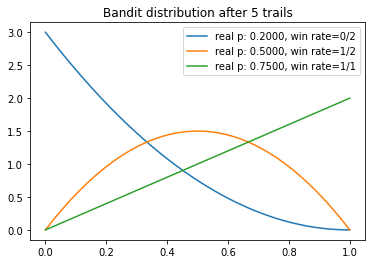

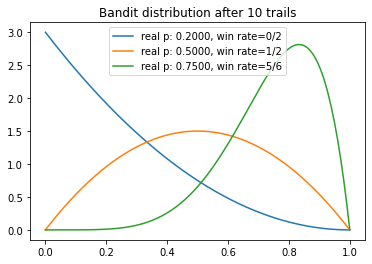

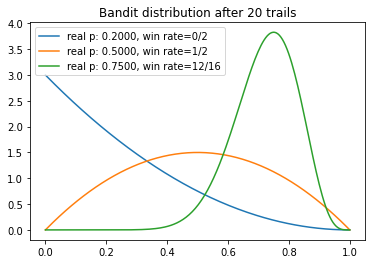

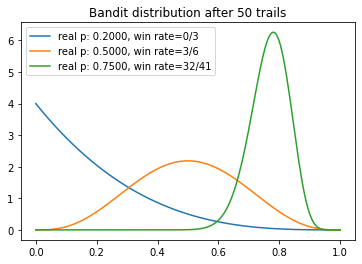

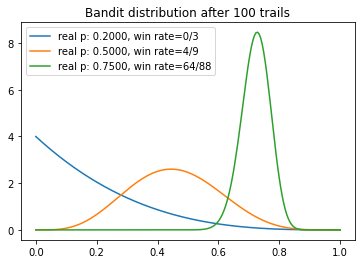

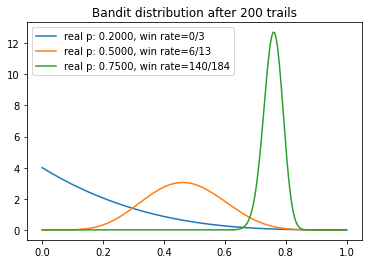

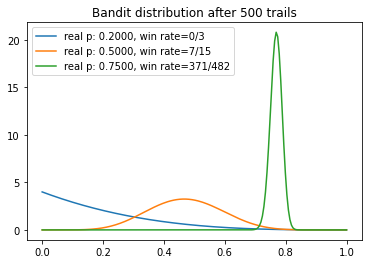

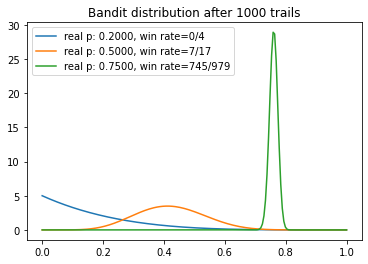

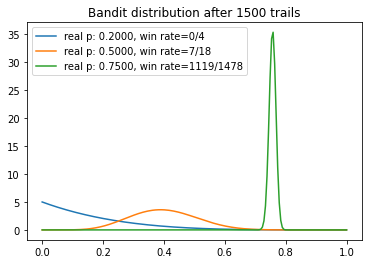

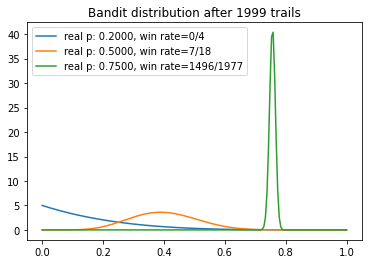

total reward earned: 1504.0
overall win rate: 0.752
num times selected each bandit: [4, 18, 1978]


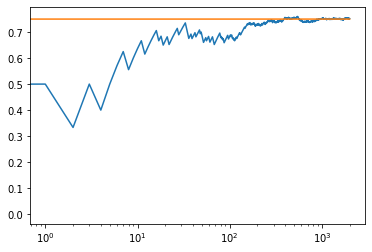

In [31]:
if __name__ =="__main__":
    experiment()